<a href="https://colab.research.google.com/github/Lqhuy125/machine_learning/blob/develop/528_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

from google.colab import drive
# drive.mount('/content/sample_data')

df  = pd.read_csv("/content/synthetic_IMU_dataset.csv")
#528_rows_2 must be in the root folder of your google drive.
df.head(5)

,aX,aY,aZ,gX,gY,gZ,id,t(s)
0,-2.953950,-4.040625,0.167477,-2.386753,-4.968418,-1.318899,2,0.000000
1,5.138598,-9.633827,0.900895,-3.116733,-0.543685,0.634777,0,0.016667
2,5.581401,-8.608281,0.536702,-4.649985,2.408268,1.180282,0,0.033333
3,-8.146595,-0.147696,0.118972,1.762254,1.106112,1.445068,3,0.050000
4,-10.059118,0.963266,0.640219,-1.655179,-2.775667,-1.397802,2,0.066667


In [10]:
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
X = df[['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ']]
y = df['id']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_selection = KNeighborsClassifier()
#print(KNeighborsClassifier().get_params().keys())
model_selection.fit(X_train, y_train)
predictions = model_selection.predict(X_test)
print(predictions)
# plt.scatter(predictions, y_train)


[3 2 0 ... 1 2 0]


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=1))
])


pred1 = pipe.fit(X_train, y_train).predict(X_test)
print(pred1)
#y_train = np.arange(0,len(y_train),1)


[3 2 0 ... 1 2 0]


In [15]:
from sklearn.model_selection import GridSearchCV
print(KNeighborsClassifier().get_params().keys())
print(y_train)
print(len(np.unique(y_train)))

mod = GridSearchCV(estimator = pipe,
                   param_grid={
                       'model__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                   },
                   cv = 2)
y_pred = mod.fit(X_train, y_train)
best_params = mod.best_params_
best_mod = mod.best_estimator_
y_pred = best_mod.fit(X_train, y_train).predict(X_test)
pd.DataFrame(mod.cv_results_)

# plt.figure(figsize=(8, 6))
# plt.scatter(y_pred, y_test)
# plt.show()

# In ra dự đoán của KNN model
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])
39087    2
30893    2
45278    2
16398    0
13653    3
        ..
11284    1
44732    2
38158    3
860      0
15795    0
Name: id, Length: 40000, dtype: int64
4
0.8965


In [17]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(accuracy)

0.9292


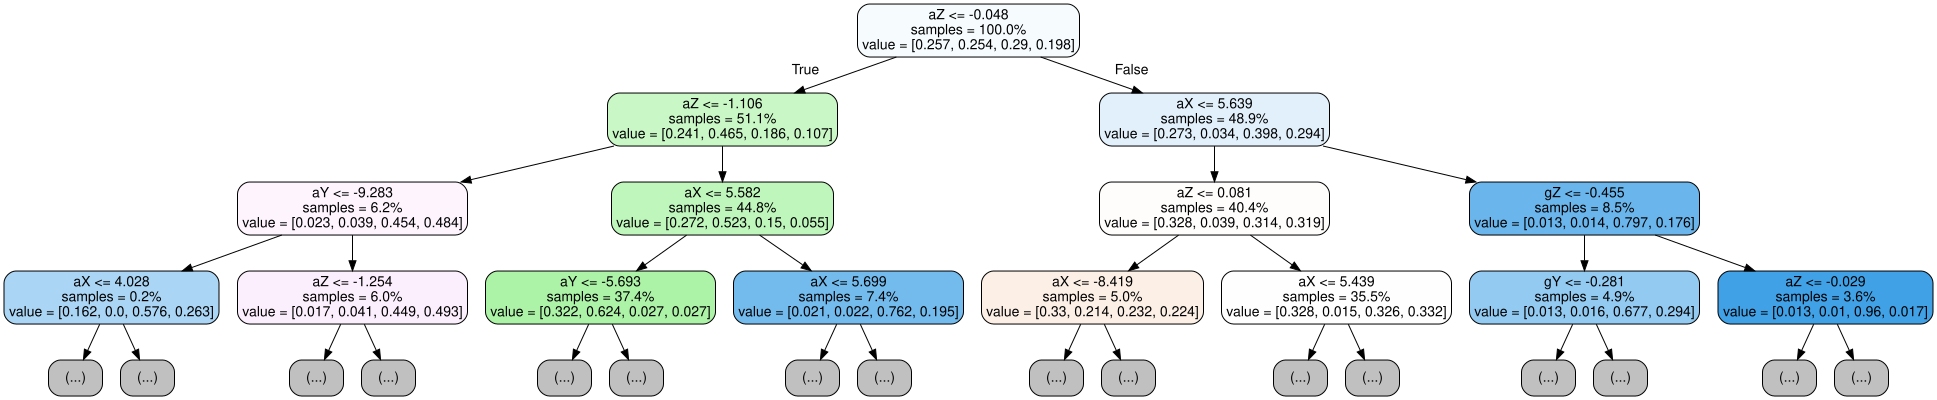

In [18]:
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

for i in range(3):
  tree = rf.estimators_[i]
  dot_data = export_graphviz(
      tree, feature_names=X.columns,
      filled=True, rounded=True,
      impurity=False, proportion=True,
      max_depth=3
  )
graph = graphviz.Source(dot_data)
display(graph)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

#print(RandomForestClassifier().get_params().keys())

rf2 = RandomForestClassifier()
rand_search = RandomizedSearchCV(rf2,
                                 param_distributions = {'n_estimators': randint(50,500),
                                                        'max_depth': randint(1,20)},
                                 n_iter=5, cv=2)
y_pred = rand_search.fit(X_train, y_train)
best_params = rand_search.best_params_
best_mod = rand_search.best_estimator_
y_pred = best_mod.fit(X_train, y_train).predict(X_test)
pd.DataFrame(rand_search.cv_results_)
print(accuracy_score(y_test, y_pred))
'''
tuned = rand_search.best_params_
best_mod = rand_search.best_estimator_
y_pred = best_mod.fit(X_train, y_train).predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)'''


In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

N = 50000
fs = 60  # tần số lấy mẫu (Hz)
dt = 1/fs

data = []

for _ in range(N):

    # default random features + noise
    aX = np.random.uniform(-10, 10) + np.random.normal(0, 0.4)
    aY = np.random.uniform(-10, 10) + np.random.normal(0, 0.4)
    aZ = np.random.uniform(-2, 2)   + np.random.normal(0, 0.1)
    gX = np.random.uniform(-5, 5)   + np.random.normal(0, 0.3)
    gY = np.random.uniform(-5, 5)   + np.random.normal(0, 0.3)
    gZ = np.random.uniform(-2, 2)   + np.random.normal(0, 0.1)

    overlap = np.random.uniform(-0.2, 0.2)

    if aX <= 5.568 + overlap:
        aY = np.random.uniform(-10, 3) + np.random.normal(0, 0.5)
        aZ = np.random.uniform(-1, 1)  + np.random.normal(0, 0.1)

        if aY <= -5.644 + overlap:
            label = 0
            gX = np.random.uniform(-5, 3) + np.random.normal(0, 0.5)
            gY = np.random.uniform(-3, 3) + np.random.normal(0, 0.5)
        else:
            if aZ <= -0.042 + overlap:
                label = 1
                gY = np.random.uniform(-1, 4) + np.random.normal(0, 0.4)
            else:
                if gY <= -0.067 + overlap:
                    label = 2
                    gX = np.random.uniform(-3, 4) + np.random.normal(0, 0.4)
                else:
                    label = 3
                    gX = np.random.uniform(-2, 4) + np.random.normal(0, 0.4)
    else:
        gZ = np.random.uniform(-2, 0.7) + np.random.normal(0, 0.1)
        aZ = np.random.uniform(-2, 1.2) + np.random.normal(0, 0.1)
        gY = np.random.uniform(-3, 1)   + np.random.normal(0, 0.3)

        if gZ <= -0.469 + overlap:
            if aZ <= -1.276 + overlap:
                label = 3
            else:
                if gY <= -0.298 + overlap:
                    label = 2
                else:
                    label = 3
        else:
            label = 2

    if np.random.rand() < 0.05:
        label = np.random.choice([0,1,2,3])

    data.append([aX, aY, aZ, gX, gY, gZ, label])

df = pd.DataFrame(data, columns=["aX","aY","aZ","gX","gY","gZ","id"])

# Thêm cột thời gian t(s)
df["t(s)"] = np.arange(N) * dt

df.to_csv("synthetic_IMU_dataset.csv", index=False)

print("Done!")


Done!
